# Introduction To Machine Learning

A Subset of AI, where machine learns own its own by understanding the pattern of a given data

## Types of ML
#### Supervised ML
- Labelled data: Input ==> Output (Given)
    - x: features, y: target
    - ex: House price prediction,
        GDP, sales, profit,
        Rainfall in mm,
        Cancer prediction, Rainfall prediction
- 80% of the problems are solved by this technique
##### Type of Supervised ML
- Regression Problem: Output value is numerical.
    -ex: sales, House Price, GDP etc
- Classification Problem: Output value is categorical
    - ex: Stock up or down, will pass or fail
    ###### Classification is of 2 type 
    - Binary: 
        Yes | No
    - Multiclass:
        flower details like length, width==> predict species[rose, lily, sunflower]
#### Unsupervised ML
- No labelled data: Only input
- Divide dataset into different clusters | groups
- Clustering Technique
- ex: DM, YT video, Insta, Amazon book, Any recommendation
#### Reinforcement ML
- ML defined an agent and it intereact with its environment and take decision based on trial and error
- ex: Self Driving Car, AI Robots, AI games

# Implement Basic ML Liner Regression using Python

In [1]:
# Liner Regression: Model understand pattern distribution and create a best fit line using Stats concept.
# Equation of Line: y = mx+c
# y: variable dependent on x
# x: independent feature
# m: slope: r.o.c of (y) w.r.t (x)  ===> w(weights): angel from x
# c: intercept ===> b(bias): value of y when x=0

In [2]:
#step 1: Load Modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import root_mean_squared_error
import os
import warnings
warnings.filterwarnings('ignore')
print('All Module Loaded Successfully!')

All Module Loaded Successfully!


In [4]:
#Load dataset 
url="https://raw.githubusercontent.com/axisgras-hash/DATASETS/refs/heads/main/india_per_capita.csv"
df=pd.read_csv(url)
print("Done")

Done


In [6]:
# Step 3: EDA
df.shape

(65, 2)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65 entries, 0 to 64
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   year                     65 non-null     int64  
 1   per capita income (US$)  65 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 1.1 KB


In [8]:
df

,year,per capita income (US$)
0,1960,84.932808
1,1961,87.853861
2,1962,92.199958
3,1963,103.435021
4,1964,117.856431
...,...,...
60,2020,1907.042516
61,2021,2239.613844
62,2022,2347.448294
63,2023,2530.120313


In [18]:
# Divide dataset into 2 groups
# x and y
# x: All features
# y: Only target

X=df[['year']]
X.sample()

,year
27,1987


In [24]:
y=df.iloc[:,-1]
y.sample(5)

24     281.049868
41     450.357901
36     401.046755
58    1966.254552
54    1553.883961
Name: per capita income (US$), dtype: float64

In [22]:
# corr b/w x&y
df.corr()

,year,per capita income (US$)
year,1.000000,0.872553
per capita income (US$),0.872553,1.000000


In [23]:
#0.872553 High +ve Correlation

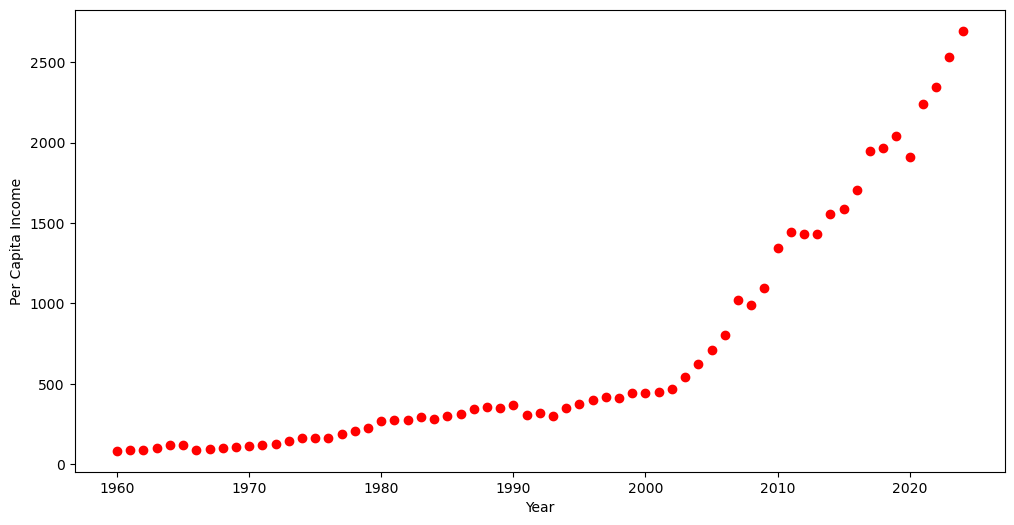

In [26]:
#plot per capita vs year
plt.figure(figsize =(12,6))
plt.scatter(X,y, color='r')
plt.xlabel("Year")
plt.ylabel("Per Capita Income")
plt.show()

In [37]:
#Update X & y
new_df=df[df['year']>=2000]
new_df

,year,per capita income (US$)
40,2000,442.750219
41,2001,450.357901
42,2002,469.149929
43,2003,544.143133
44,2004,624.258827
45,2005,710.488080
46,2006,801.668354
47,2007,1021.887077
48,2008,992.519585
49,2009,1094.949746


In [33]:
X=new_df[['year']]
y=new_df.iloc[:,-1]

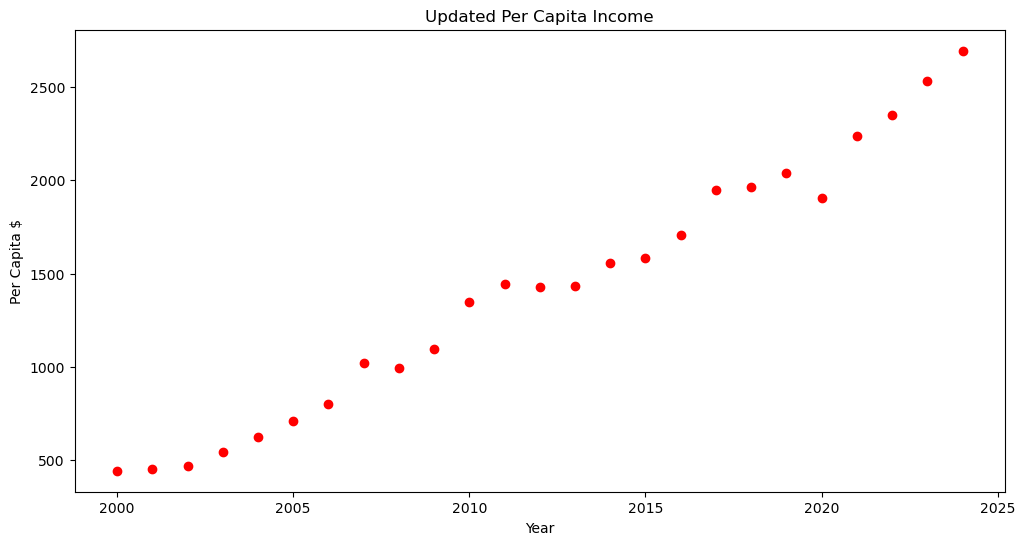

In [34]:
# Plot Per Capita Income vs Year
plt.figure(figsize =(12,6))
plt.title("Updated Per Capita Income")
plt.scatter(X,y, color='r')
plt.xlabel("Year")
plt.ylabel("Per Capita $")
plt.show()

In [35]:
#Model building using Linear Regression
model= LinearRegression() #object creation
model.fit(X,y)
#training step(Model learns and find best fit line)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[92.21]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['year']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.841e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [36]:
# Model Prediction of same X data
# model y predict(X)
y_pred=model.predict(X)
y_pred

array([ 306.61108656,  398.82503329,  491.03898002,  583.25292675,
        675.46687349,  767.68082022,  859.89476695,  952.10871368,
       1044.32266041, 1136.53660714, 1228.75055387, 1320.9645006 ,
       1413.17844734, 1505.39239407, 1597.6063408 , 1689.82028753,
       1782.03423426, 1874.24818099, 1966.46212772, 2058.67607445,
       2150.89002119, 2243.10396792, 2335.31791465, 2427.53186138,
       2519.74580811])

In [41]:
df_comp= new_df.copy()
df_comp['Model_y']= y_pred
df_comp['Error']=df_comp['Model_y'] - df_comp.iloc[:,-2]
df_comp

,year,per capita income (US$),Model_y,Error
40,2000,442.750219,306.611087,-136.139132
41,2001,450.357901,398.825033,-51.532867
42,2002,469.149929,491.038980,21.889051
43,2003,544.143133,583.252927,39.109793
44,2004,624.258827,675.466873,51.208047
45,2005,710.488080,767.680820,57.192740
46,2006,801.668354,859.894767,58.226413
47,2007,1021.887077,952.108714,-69.778363
48,2008,992.519585,1044.322660,51.803076
49,2009,1094.949746,1136.536607,41.586861


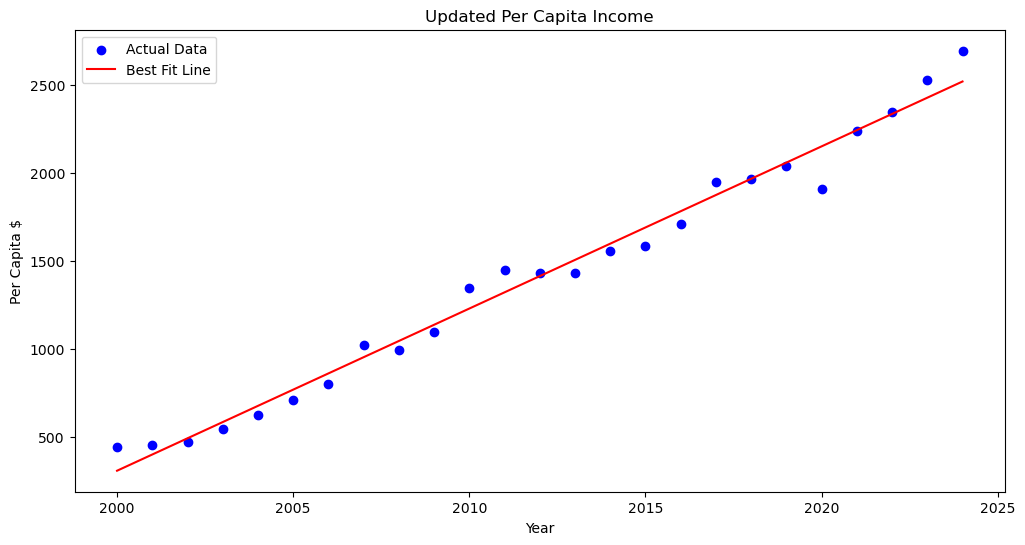

In [44]:
# Model best fit line
plt.figure(figsize =(12,6))
plt.title("Updated Per Capita Income")
plt.scatter(X,y, color='b', label='Actual Data')
plt.plot(X,y_pred, color='r', label='Best Fit Line')
plt.xlabel("Year")
plt.ylabel("Per Capita $")
plt.legend()
plt.show()

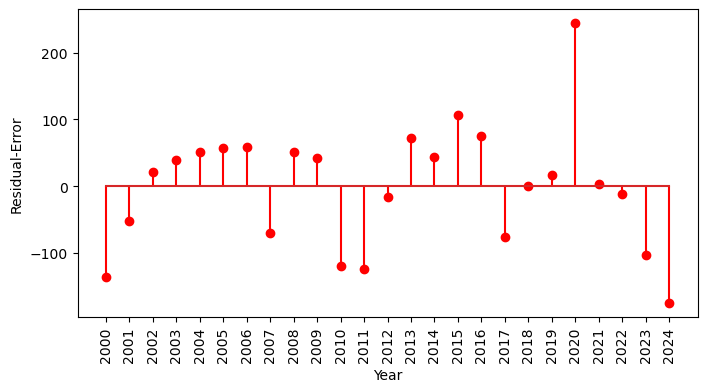

In [46]:
# Residual Plot: to identify model mistakes
plt.figure(figsize=(8,4))
plt.stem(df_comp['Error'], linefmt='r-')
plt.xticks(range(25), df_comp['year'], rotation=90)
plt.xlabel("Year")
plt.ylabel("Residual-Error")
plt.show()

In [52]:
#Next 5 years Per-Capita Forecasting
next_5_year=[[i] for i in range(2025,2030)]
model_ans= model.predict(next_5_year)
forecast_df=pd.DataFrame({'Next-5-year':next_5_year,
                         'Prediction-Per-Capital':model_ans})
forecast_df

,Next-5-year,Prediction-Per-Capital
0,[2025],2611.959755
1,[2026],2704.173702
2,[2027],2796.387648
3,[2028],2888.601595
4,[2029],2980.815542


In [53]:
# H/w (Data from World Bank)
# GDP Prediction India,
# China Per-Capita Prediction

In [54]:
def predict_per_capita(year):
    ans= model.predict([[year]])[0]
    print('Estimated prediction: ',ans)

In [57]:
predict_per_capita(2029)

Estimated prediction:  2980.815541766904


# Model Evaluation
- MSE: mean squared error
- MAE: mean absolute error
- RMSE: root mean squared error
- R2_score

MAE= 1/n Σ|y-y^|
- y (y_i): Actual output
- y^ (y_cap): predicted output

MSE: 

RMSE= Square root of (Σ((y - y^)^2)/n)